In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [74]:
import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")


In [2]:
df=pd.read_csv(r'C:\Users\Aanchal Surana\OneDrive\Desktop\MCA\titanic.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Gender       891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Gender           0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
df.shape

(891, 12)

In [8]:
round(((df.isnull().sum())/df.shape[0])*100,2)

PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Gender          0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64

In [9]:
df.columns[round(((df.isnull().sum())/df.shape[0])*100,2)>20]

Index(['Cabin'], dtype='object')

In [10]:
#df.drop(columns=['Cabin'])  #temp delete
df.drop(columns=['Cabin'],inplace=True) #permanent delete

In [11]:
set(df.select_dtypes(include=['int','float']).columns)

{'Age', 'Fare', 'Parch', 'PassengerId', 'Pclass', 'SibSp', 'Survived'}

In [12]:
set(df.columns[(df.isnull().sum())>0])

{'Age', 'Embarked'}

In [13]:
set(df.select_dtypes(include=['int','float']).columns) & set(df.columns[(df.isnull().sum())>0])

{'Age'}

In [14]:
df['Age'].median()

28.0

In [15]:
df['Age']=df['Age'].fillna(df['Age'].median())

In [16]:
df['Age']

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    28.0
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [17]:
set(df.select_dtypes(include=['object']).columns) & set(df.columns[(df.isnull().sum())>0])

{'Embarked'}

In [18]:
df['Embarked'].value_counts().index[0]

'S'

In [19]:
df['Embarked']=df['Embarked'].fillna(df['Embarked'].value_counts().index[0])

In [20]:
df['Embarked']

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: object

In [21]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Gender         0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [22]:
df['Initial']=0
for i in df:
    df['Initial']=df.Name.str.extract('([A-Za-z]+)\.')

In [23]:
df['Initial']

0        Mr
1       Mrs
2      Miss
3       Mrs
4        Mr
       ... 
886     Rev
887    Miss
888    Miss
889      Mr
890      Mr
Name: Initial, Length: 891, dtype: object

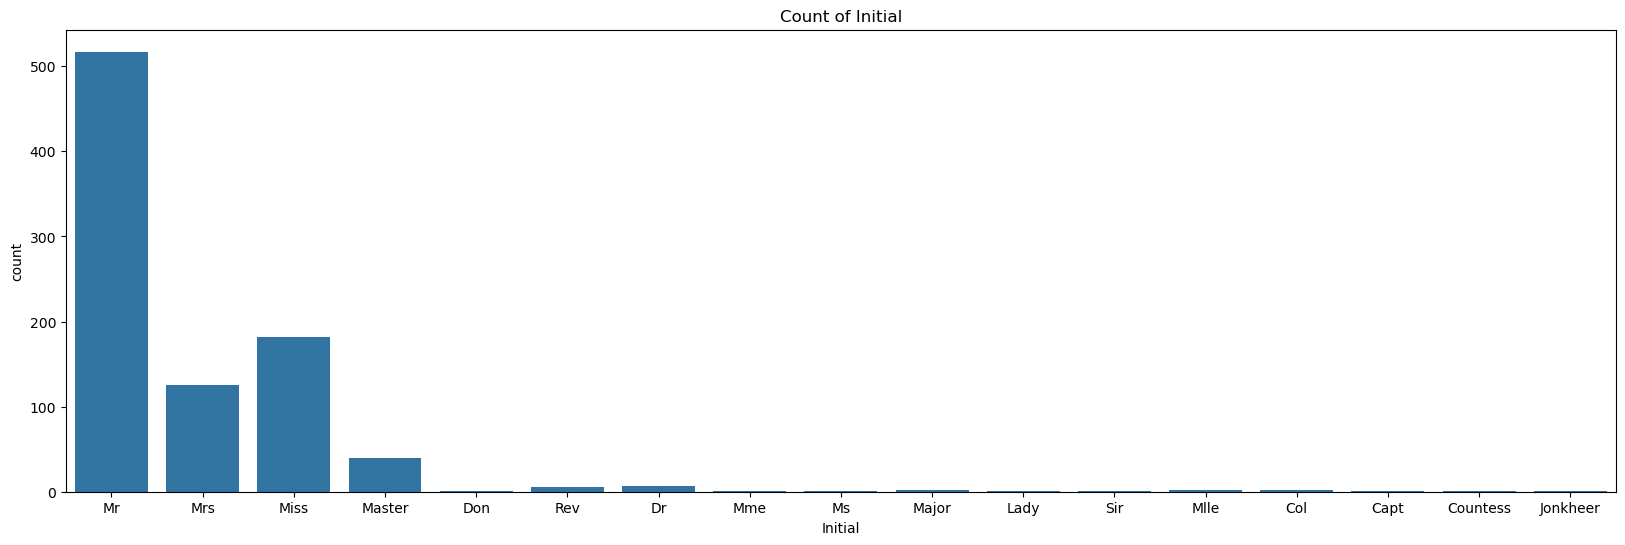

In [24]:
plt.figure(figsize=(20,6))  
sns.countplot(x=df['Initial'])
plt.title("Count of Initial")
plt.show()

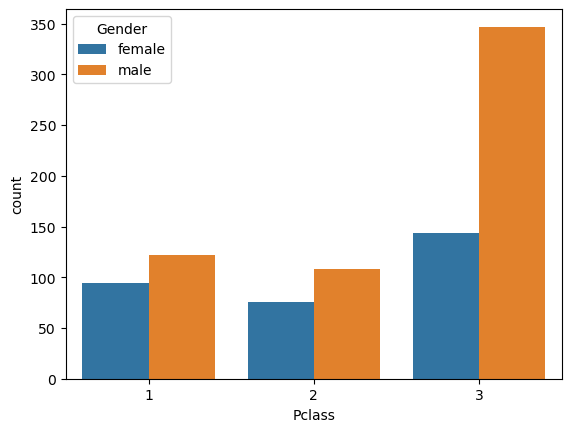

In [25]:
sns.countplot(x='Pclass',hue='Gender',data=df)
plt.show()

<Axes: xlabel='Survived', ylabel='count'>

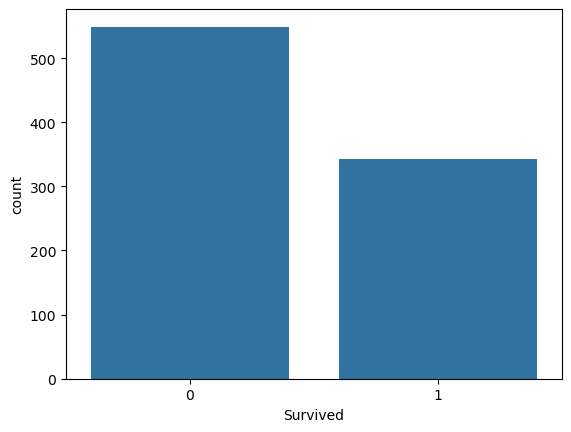

In [26]:
sns.countplot(x='Survived', data=df)

<Axes: >

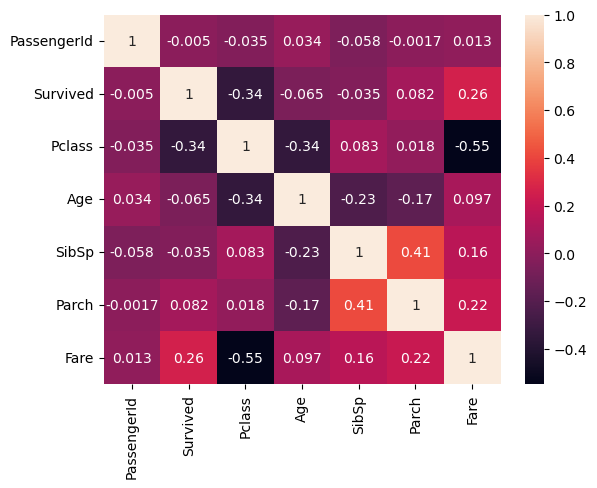

In [27]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

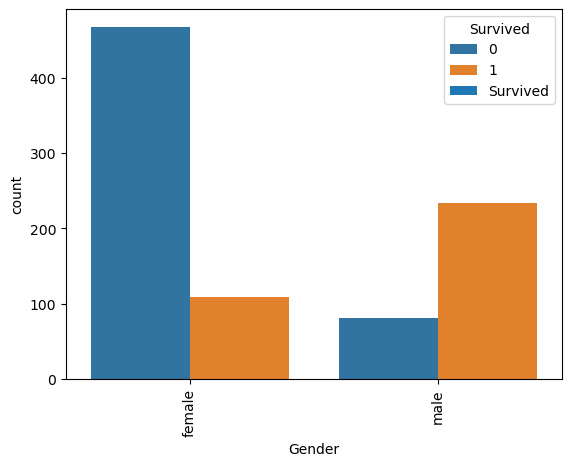

In [28]:
df[['Gender','Survived']].groupby(['Gender']).mean().plot.bar()
sns.countplot(x='Gender',hue='Survived',data=df)
plt.show()

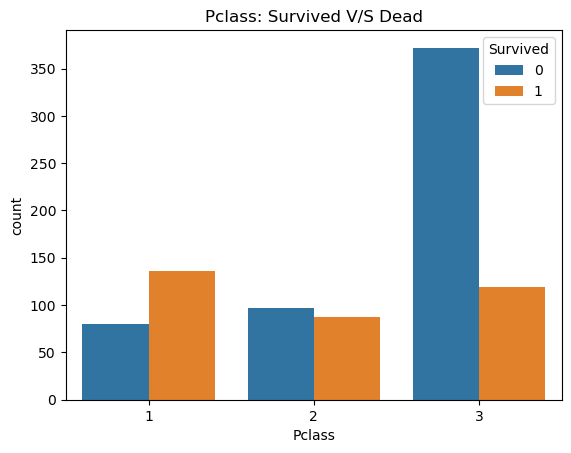

In [29]:
sns.countplot(x='Pclass',hue='Survived',data=df)
plt.title('Pclass: Survived V/S Dead')
plt.show()

In [30]:
pd.crosstab(index=[df.Gender,df.Survived],columns=df.Pclass,margins=True,margins_name='Total').astype(int).style.background_gradient(cmap='summer_r')

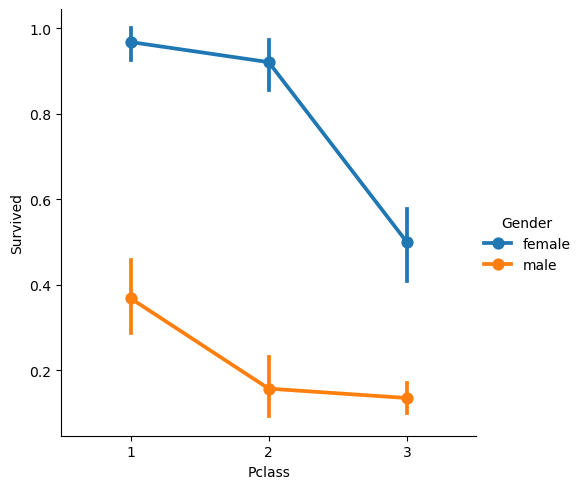

In [31]:
sns.catplot(x='Pclass',y='Survived',hue='Gender',data=df,kind='point')
plt.show()

In [32]:
df['Age'].max()

80.0

In [33]:
print("older person survived was of",df['Age'].max())
print("youngest person survived was of",df['Age'].min())
print("avg person survived was of",df['Age'].mean())

older person survived was of 80.0
youngest person survived was of 0.42
avg person survived was of 29.36158249158249


In [34]:
print(df['Initial'].unique())

['Mr' 'Mrs' 'Miss' 'Master' 'Don' 'Rev' 'Dr' 'Mme' 'Ms' 'Major' 'Lady'
 'Sir' 'Mlle' 'Col' 'Capt' 'Countess' 'Jonkheer']


In [35]:
pd.crosstab(df.Initial,df.Gender).T.style.background_gradient(cmap='summer_r')

Initial,Capt,Col,Countess,Don,Dr,Jonkheer,Lady,Major,Master,Miss,Mlle,Mme,Mr,Mrs,Ms,Rev,Sir
Gender,,,,,,,,,,,,,,,,,
female,0,0,1,0,1,0,1,0,0,182,2,1,0,125,1,0,0
male,1,2,0,1,6,1,0,2,40,0,0,0,517,0,0,6,1


In [36]:
df['Initial'].replace(['Mr', 'Mrs' ,'Miss' ,'Master' ,'Don' ,'Rev' ,'Dr' ,'Mme' ,'Ms' ,'Major' ,'Lady', 'Sir' ,'Mlle', 'Col', 'Capt', 'Countess', 'Jonkheer'],['Miss','Miss','Miss','Mr','Mr','Mrs','Mrs','Other','Other','Other','Mr','Mr','Mr','Mr','Mr','Mr','Mr'],inplace=True)

In [37]:
pd.crosstab(df.Initial,df.Gender).T.style.background_gradient(cmap='summer_r')

Initial,Miss,Mr,Mrs,Other
Gender,,,,
female,307,4,1,2
male,517,46,12,2


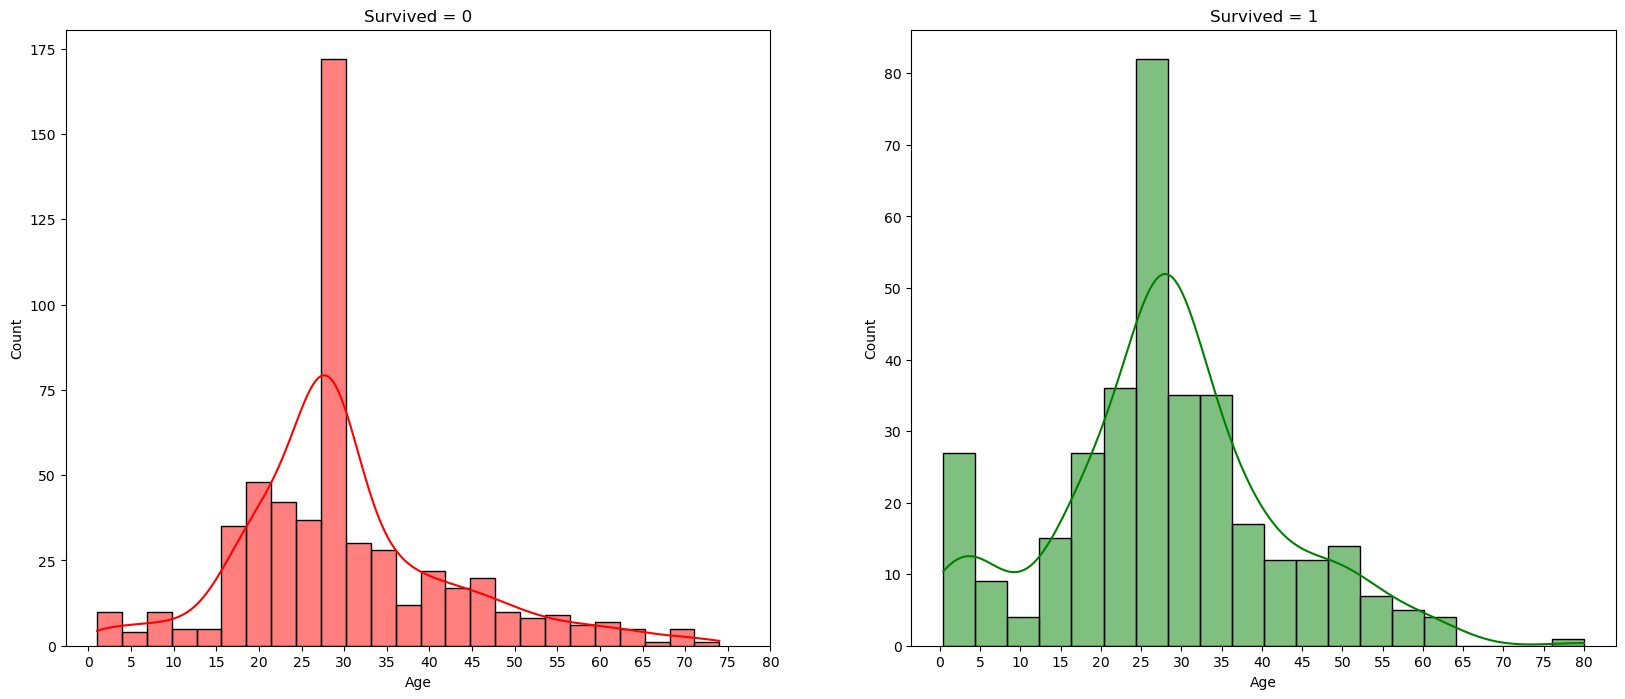

In [38]:
f,ax=plt.subplots(1,2,figsize=(20,8))
sns.histplot(df[df['Survived']==0].Age,kde=True,ax=ax[0],color='red')
ax[0].set_title('Survived = 0')
x1=list(range(0,85,5))
ax[0].set_xticks(x1)
sns.histplot(df[df['Survived']==1].Age,kde=True,ax=ax[1],color='green')
x2=list(range(0,85,5))
ax[1].set_xticks(x2)
ax[1].set_title('Survived = 1')
plt.show()

<h5>Data Encoding = convert object (categorical) column to numeric

In [39]:
df.drop(columns=['PassengerId','Name'],inplace=True)

In [40]:
df.select_dtypes(include=['int','float']).columns

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

<h5>Treating Outliers

In [41]:
def outlier(df,i):
    q1=np.percentile(df[i],25)
    q3=np.percentile(df[i],75)
    iqr=q3-q1
    lower_fence=q1-(iqr*1.5)
    upper_fence=q3+(iqr*1.5)
    df[i]=np.where(((df[i]<lower_fence)|(df[i]>upper_fence)),df[i].median(),df[i])
for j in ['Survived','Pclass','Age','SibSp','Parch','Fare']:
    outlier(df,j)

<h5>difference in std because outlier is removed


In [42]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.0,891.000000
mean,0.383838,2.308642,28.476992,0.297419,0.0,17.383622
std,0.486592,0.836071,9.793559,0.521648,0.0,12.713016
min,0.000000,1.000000,3.000000,0.000000,0.0,0.000000
25%,0.000000,2.000000,23.750000,0.000000,0.0,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.0,14.454200
75%,1.000000,3.000000,33.000000,1.000000,0.0,24.150000
max,1.000000,3.000000,54.000000,2.000000,0.0,65.000000


In [43]:
x=df.drop(columns=['Survived'])
y=df['Survived']

In [44]:
x.drop(columns=['Initial'],inplace=True)

In [45]:
x.select_dtypes(exclude=['int','float']).columns


Index(['Gender', 'Ticket', 'Embarked'], dtype='object')

In [46]:
def main(x,i):
    x[i]=x[i].map(x[i].value_counts().to_dict())
for j in ['Gender','Ticket','Embarked']:
    main(x,j)

In [47]:
from sklearn.preprocessing import StandardScaler
s=StandardScaler()
x=s.fit_transform(x)
x=pd.DataFrame(x)
x.columns=['Pclass','Gender','Age','SibSp','Parch','Ticket','Fare','Embarked']
x.head()

,Pclass,Gender,Age,SibSp,Parch,Ticket,Fare,Embarked
0,0.827377,0.737695,-0.661724,1.347605,0.0,-0.579162,-0.797554,0.612906
1,-1.566107,-1.355574,0.972921,1.347605,0.0,-0.579162,-0.230556,-1.490235
2,0.827377,-1.355574,-0.253063,-0.570472,0.0,-0.579162,-0.744429,0.612906
3,-1.566107,-1.355574,0.666425,1.347605,0.0,0.155928,2.811012,0.612906
4,0.827377,0.737695,0.666425,-0.570472,0.0,-0.579162,-0.734591,0.612906


In [48]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain, ytest = train_test_split(x, y, test_size=0.3, random_state=42)
xtrain.shape, ytrain.shape, xtest.shape, ytest.shape

((623, 8), (623,), (268, 8), (268,))

In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,confusion_matrix
l =LogisticRegression()
l.fit(xtrain,ytrain)
train_pred = l.predict(xtrain)

In [50]:
print(f'training accuracy is {accuracy_score(train_pred,ytrain)}')
test_pred = l.predict(xtest)
print(f'testing accuracy is {accuracy_score(test_pred,ytest)}')
print("R2_score:",r2_score(train_pred,ytrain))
print("MSE:",mean_squared_error(ytrain,train_pred))
print("Classification report:",classification_report(ytest,test_pred))
print("confusion matrix RF:\n",confusion_matrix(ytest,test_pred))

training accuracy is 0.8009630818619583
testing accuracy is 0.7798507462686567
R2_score: 0.11540135119661066
MSE: 0.19903691813804172
Classification report:               precision    recall  f1-score   support

         0.0       0.80      0.83      0.82       157
         1.0       0.75      0.71      0.73       111

    accuracy                           0.78       268
   macro avg       0.77      0.77      0.77       268
weighted avg       0.78      0.78      0.78       268

confusion matrix RF:
 [[130  27]
 [ 32  79]]


In [51]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error
t=LinearRegression()
t.fit(xtrain,ytrain)

LinearRegression()

In [52]:
trpredict=t.predict(xtrain)

In [53]:
print("R2_score:",r2_score(trpredict,ytrain))
print("MSE:",mean_squared_error(ytrain,trpredict))

R2_score: -0.7445773318644116
MSE: 0.1482984823873235


In [54]:
#print("R2_score:",r2_score(tst_pred,ytest))
#print("MSE:",mean_squared_error(ytest,tst_pred))
#print("MAE:",mean_absolute_error(ytest,tst_pred))

In [55]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report
rf=RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(xtrain,ytrain)

RandomForestClassifier(random_state=42)

In [56]:
y_pred=rf.predict(xtest)
y_pred=rf.predict(xtrain)


In [57]:
print("Test Accuracy:",accuracy_score(ytrain,y_pred))
print("Train Accuracy:",accuracy_score(ytrain,y_pred))
print("R2_score:",r2_score(y_pred,ytrain))
print("MSE:",mean_squared_error(ytrain,y_pred))
print("MAE:",mean_absolute_error(ytrain,y_pred))
print("classification  report:",classification_report(ytrain,y_pred))
print("confusion matrix RF:\n",confusion_matrix(ytrain,y_pred))

Test Accuracy: 0.9759229534510433
Train Accuracy: 0.9759229534510433
R2_score: 0.8950259486419088
MSE: 0.024077046548956663
MAE: 0.024077046548956663
classification  report:               precision    recall  f1-score   support

         0.0       0.97      0.99      0.98       392
         1.0       0.99      0.95      0.97       231

    accuracy                           0.98       623
   macro avg       0.98      0.97      0.97       623
weighted avg       0.98      0.98      0.98       623

confusion matrix RF:
 [[389   3]
 [ 12 219]]


In [58]:
#%pip install xgboost

In [59]:
#import xgboost as xgb
#from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
#from xgboost import XGBClassifier
#model=XGBClassifier()
#model.fit(xtrain,ytrain)

In [60]:
#y_xgpred=model.predict(xtest)
#y_xgtpred=model.predict(xtrain)

In [61]:
#print("Test Accuracy:",accuracy_score(ytest,y_xgpred))
#print("Train Accuracy:",accuracy_score(ytrain,y_xgtpred))
#print("R2_score:",r2_score(y_xgtpred,ytrain))
#print("MSE:",mean_squared_error(ytrain,y_xgtpred))
#print("Classification Report:",classification_report(ytest,y_xgpred))
#print("Confusion matrix RF:",confusion_matrix(ytest,y_xgpred))

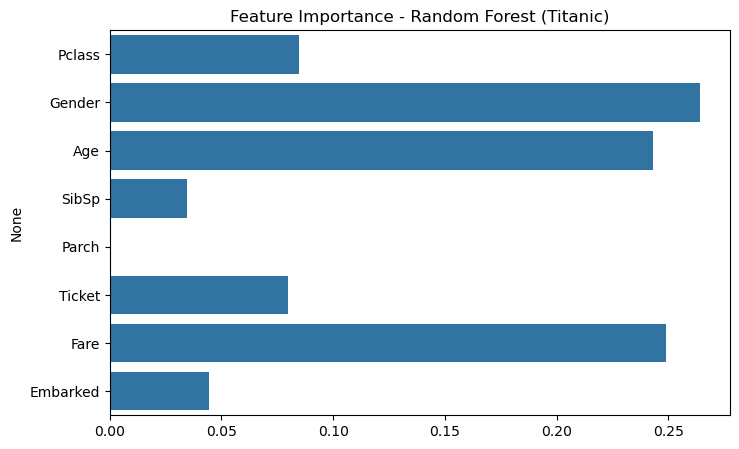

In [62]:
importances = rf.feature_importances_
features = x.columns
plt.figure(figsize=(8,5))
sns.barplot(x=importances,y=features)
plt.title("Feature Importance - Random Forest (Titanic)")
plt.show()

In [63]:
#DEPLOYMENT 

In [64]:
import joblib
joblib.dump(rf,"titanic_model_.pkl")
joblib.dump(s,"scaler.pkl")


['scaler.pkl']

In [65]:
# Load model & scaler back (in real use case, you would load them)
model = joblib.load("titanic_model_.pkl")
scaler = joblib.load("scaler.pkl")

def predict_survival(Pclass, Gender, Age, SibSp, Parch, Pare, Ticket, Embarked):
    # Convert categorical to numeric like you did in preprocessing
    gender_map = {"male":0,"female":1} # Creates dictionaries to convert text values(male/female, embarkaton ports S/C/Q) into numbers.
    Embarked_map = {"S": 0,"C": 1,"Q": 2} #This matches the preprocessing we did earlier when training the model. # simplified mapping

    Gender =  gender_map.get(Gender.lower(),0) #Converts the user's input into numeric values.
    Embarked = Embarked_map.get(Embarked.upper(),0) # dictionary.get(key,default_value) if the input doesn't match,it defaults to 0

    # Create dataframe for a single row
    input_data = pd.DataFrame([[Pclass, Gender, Age, SibSp, Parch, Ticket, Fare, Embarked]],
                             columns = ['Pclass','Gender','Age','SibSp', 'Parch','Ticket','Fare','Embarked']) # incomplete
    # Scale the input (important!)
    input_scaled = scaler.transform(input_data)

    ## Ensures new inputs are transformed(mean =0, std = 1) like the training  data , otherwise predict
    # input_sc_aled = pd.DataFrame(input_scaled, columns = input_data.columns) # to remove the warning in 

    # Predict
    prediction = model.predict(input_scaled)[0] # indexing 0 becomes we  are giving 1 passenger input only otherwise --

    if prediction ==1:
        return "Survived"
    else:
        return "Did not survive"

In [70]:
Pclass = int(input("Passenger Class (1,2,3): "))
Gender = input("Gender (male/Female): ")
Age = float(input("Age:"))
SibSp =int( input("Number of Siblings/Spouses aboard:"))
Parch = int(input("Number of Parents/Children aboard:"))
Fare = float(input("Ticket Fare:"))
Ticket = int(input("Ticket number (any integer):"))
Embarked = input("Port of Embarkation (S, C, Q): ")
result = predict_survival(Pclass,Gender,Age,SibSp,Parch,Fare,Ticket,Embarked)
print("\nPrediction:",result)

Passenger Class (1,2,3):  1
Gender (male/Female):  male
Age: 12
Number of Siblings/Spouses aboard: 1
Number of Parents/Children aboard: 1
Ticket Fare: 200
Ticket number (any integer): 12
Port of Embarkation (S, C, Q):  S



Prediction: Survived
